# South Korea Solow-Swan and R-C-K model

In [ ]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install numpy
!pip install statsmodels


  Using cached pandas-3.0.1-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.3-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-3.0.1-cp314-cp314-win_amd64.whl (9.9 MB)
Using cached numpy-2.4.3-cp314-cp314-win_amd64.whl (12.4 MB)
Using cached tzdata-2025.3-py2.py3-none-any.whl (348 kB)

   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------

In [1]:
pip install requests

  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
Using cached requests-2.32.5-py3-none-any.whl (64 kB)
Using cached idna-3.11-py3-none-any.whl (71 kB)
Using cached urllib3-2.6.3-py3-none-any.whl (131 kB)
Using cached certifi-2026.2.25-py3-none-any.whl (153 kB)

   ---------------------------------------- 0/5 [urllib3]
   ---------------------------------------- 0/5 [urllib3]
   ---------------------------------------- 0/5 [urllib3]
   ---------------------------------------- 0/5 [urllib3]
   -------- ------------------------------- 1/5 [idna]
   -------- ------------------------------- 1/5 [idna]
   ---------------- ----------------------- 2/5 [charset_normalizer]
   ------------------------ --------------- 3/5 [certifi]
   -------------------------------- ------- 4/5 [requests]
 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import requests


In [7]:
!pip install openpyxl
import openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   ---------------------------------------- 0/2 [et-xmlfile]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ----------------

In [4]:
# read the excel file 
df = pd.read_excel(r'C:\Users\dell\OneDrive\Documents\SSE\GD\pwt110.xlsx', sheet_name= 'Sheet2')
df

,year,rgdpe,rgdpo,cgdpe,cgdpo,cn,rgdpna,rconna,rdana,rnna,pop,emp,irr,delta,rtfpna,export,trade,high_exports,gfcf
0,1957,3.268756e+04,3.295155e+04,3.436359e+04,3.403884e+04,2.155726e+05,4.461884e+04,4.909672e+04,5.052773e+04,1.830345e+05,22.822789,6.590466,0.114209,0.027590,0.391713,2.631579,14.553429,..,11.204147
1,1958,3.369983e+04,3.415745e+04,3.551961e+04,3.560029e+04,2.162890e+05,4.617504e+04,5.082209e+04,5.110946e+04,1.833366e+05,23.470858,6.716146,0.121510,0.027489,0.404374,4.027732,,..,11.687025
2,1959,3.408021e+04,3.486209e+04,3.585266e+04,3.632298e+04,2.139041e+05,4.699340e+04,5.288839e+04,5.106291e+04,1.819736e+05,24.205347,6.862942,0.109424,0.027258,0.414188,3.863946,19.401361,..,13.768707
3,1960,3.409043e+04,3.521473e+04,3.605902e+04,3.654425e+04,2.112903e+05,4.754741e+04,5.356448e+04,5.198218e+04,1.810267e+05,25.015673,7.027187,0.119657,0.026968,0.420574,3.934741,18.522073,..,13.474088
4,1961,3.580989e+04,3.772867e+04,3.788565e+04,3.924679e+04,2.098901e+05,4.969170e+04,5.522455e+04,5.491948e+04,1.816221e+05,25.853127,7.311473,0.137279,0.026826,0.424027,4.936113,17.256221,..,11.513114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,2019,2.546968e+06,2.638620e+06,2.528384e+06,2.612106e+06,1.315183e+07,2.691550e+06,1.600018e+06,2.527542e+06,1.307992e+07,51.767846,27.127560,0.079391,0.051937,0.994751,45.294861,90.585148,36.118279,31.933893
63,2020,2.588778e+06,2.665120e+06,2.571554e+06,2.652868e+06,1.376681e+07,2.672703e+06,1.564094e+06,2.495382e+06,1.351781e+07,51.858482,26.921223,0.073534,0.052152,0.987357,41.321481,82.258009,30.27628,31.447015
64,2021,2.691083e+06,2.795994e+06,2.691083e+06,2.795994e+06,1.398631e+07,2.795994e+06,1.630350e+06,2.600358e+06,1.398631e+07,51.848397,27.296127,0.075814,0.052439,1.000000,44.358238,84.642495,36.258256,30.029371
65,2022,2.669096e+06,2.869279e+06,2.686164e+06,2.887701e+06,1.449746e+07,2.872256e+06,1.698371e+06,2.672612e+06,1.443600e+07,51.782512,28.121723,0.068568,0.052841,0.997360,..,..,..,..


In [5]:
df.index = pd.PeriodIndex(df['year'], freq='Y')
df.drop(columns=['year'], inplace=True)


In [6]:
df.columns


Index(['rgdpe', 'rgdpo', 'cgdpe', 'cgdpo', 'cn', 'rgdpna', 'rconna', 'rdana',
       'rnna', 'pop', 'emp', 'irr', 'delta', 'rtfpna', 'export', 'trade',
       'high_exports', 'gfcf'],
      dtype='str')

# barro regression


In [7]:
# tacking log of the level variable
df['log_rgdpo'] = np.log(df['rgdpo'])
df['log_rgdpe'] = np.log(df['rgdpe'])
# lag of the log variable
df['log_rgdpo_lag1'] = df['log_rgdpo'].shift(1)
df['log_rgdpe_lag1'] = df['log_rgdpe'].shift(1)

# growth rate of the level variable
df['rgdpo_growth'] = df['log_rgdpo'] - df['log_rgdpo_lag1']
df['rgdpe_growth'] = df['log_rgdpe'] - df['log_rgdpe_lag1']

In [11]:
# unconditional regression
X = df['log_rgdpe_lag1']# independent variable 
y = df['rgdpe_growth'] # dependent variable

# add a constant to the independent variable
X = sm.add_constant(X)

unc_model = sm.OLS(y, X, missing='drop').fit(cov_type='HC3')
print(unc_model.summary())

                            OLS Regression Results                            
Dep. Variable:           rgdpe_growth   R-squared:                       0.122
Model:                            OLS   Adj. R-squared:                  0.108
Method:                 Least Squares   F-statistic:                     8.351
Date:                Wed, 18 Mar 2026   Prob (F-statistic):            0.00526
Time:                        14:56:25   Log-Likelihood:                 100.86
No. Observations:                  66   AIC:                            -197.7
Df Residuals:                      64   BIC:                            -193.3
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.2376      0.062      3.

In [9]:
df['gfcf'] = pd.to_numeric(df['gfcf'], errors='coerce')
df['export'] = pd.to_numeric(df['export'], errors='coerce')
df['trade'] = pd.to_numeric(df['trade'], errors='coerce')

# creating other variables for the regression
df['emp_growth'] = np.log(df['emp']) - np.log(df['emp'].shift(1))
df['log_gfcf'] = np.log(df['gfcf'])
# creating (n+g+delta) variable
df['n_g_delta'] = np.log(df['emp_growth']) + np.log(df['rtfpna']) + np.log(df['delta'])
df['log_n_g_delta'] = df['n_g_delta']


# conditional regression
X_cond = df[['log_rgdpo_lag1', 'log_n_g_delta', 'log_gfcf']] # independent variables

#per capita output growth as the dependent variable
df['rgdpo_capita'] = df['rgdpo'] / df['emp']
df['rgdpe_capita'] = df['rgdpe'] / df['emp']

y_cond = df['rgdpo_growth'] # dependent variable
x_cond = sm.add_constant(X_cond)

cond_model = sm.OLS(y_cond, x_cond, missing='drop').fit(cov_type='HC3')
print(cond_model.summary())

                            OLS Regression Results                            
Dep. Variable:           rgdpo_growth   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.422
Method:                 Least Squares   F-statistic:                     11.65
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           5.10e-06
Time:                        14:50:33   Log-Likelihood:                 109.05
No. Observations:                  59   AIC:                            -210.1
Df Residuals:                      55   BIC:                            -201.8
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.2556      0.197      1.

c:\Users\dell\OneDrive\Documents\SSE\GD\country-specific\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [18]:
print(x_cond.dtypes)

const             float64
log_rgdpo_lag1    float64
log_n_g_delta     float64
log_gfcf          float64
dtype: object


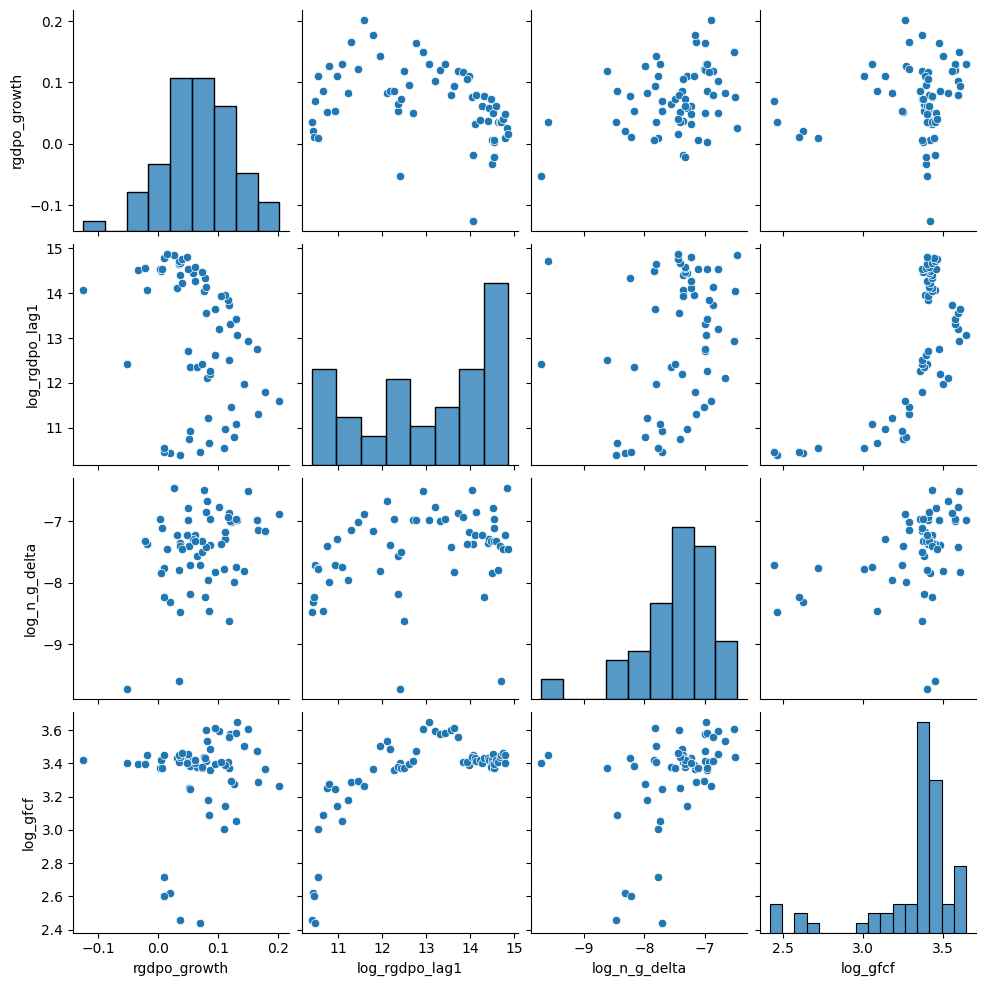

In [10]:
# relationship between each independent variable and the dependent variable
sns.pairplot(df[['rgdpo_growth', 'log_rgdpo_lag1', 'log_n_g_delta', 'log_gfcf']])
plt.show()

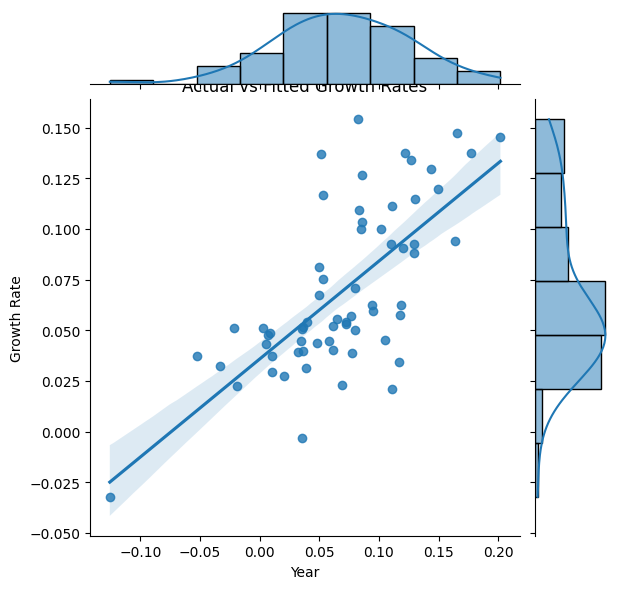

In [21]:
# plot fitted and actual values actter and line graph
df['fitted_values'] = cond_model.fittedvalues
sns.jointplot(x=df['rgdpo_growth'], y=df['fitted_values'], kind='reg')
plt.title('Actual vs Fitted Growth Rates') 
plt.xlabel('Year')
plt.ylabel('Growth Rate')
plt.show()

In [22]:
df['rgdpo']/1000

year
1957      32.951555
1958      34.157445
1959      34.862094
1960      35.214727
1961      37.728672
           ...     
2019    2638.620500
2020    2665.119500
2021    2795.993500
2022    2869.278750
2023    2912.405500
Freq: Y-DEC, Name: rgdpo, Length: 67, dtype: float64

### Distribution of real GDP

C:\Users\dell\AppData\Local\Temp\ipykernel_14484\1578337918.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['rgdpo'], label='Data Points');


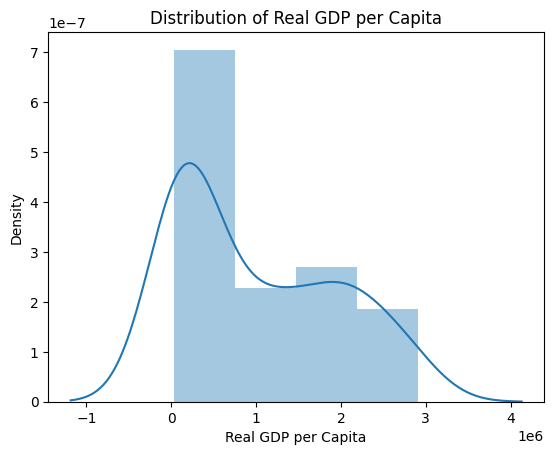

In [23]:
sns.distplot(df['rgdpo'], label='Data Points');
plt.title('Distribution of Real GDP per Capita')
plt.xlabel('Real GDP per Capita') 
plt.ylabel('Density')
plt.show()

#### production function

In [24]:
df.columns

Index(['rgdpe', 'rgdpo', 'cgdpe', 'cgdpo', 'cn', 'rgdpna', 'rconna', 'rdana',
       'rnna', 'pop', 'emp', 'irr', 'delta', 'rtfpna', 'export', 'trade',
       'high_exports', 'gfcf', 'log_rgdpo', 'log_rgdpe', 'log_rgdpo_lag1',
       'log_rgdpe_lag1', 'rgdpo_growth', 'rgdpe_growth', 'emp_growth',
       'log_gfcf', 'n_g_delta', 'log_n_g_delta', 'rgdpo_capita',
       'rgdpe_capita', 'fitted_values'],
      dtype='str')

In [25]:
# to identify alpha,beta 
df['log_emp'] = np.log(df['emp'])
df['log_capital'] = np.log(df['rnna'])

x_pro = df[['log_capital', 'log_emp']]
x_pro = sm.add_constant(x_pro)
y_pro = np.log(df['rgdpo'])

pro_model = sm.OLS(y_pro, x_pro, missing='drop').fit(cov_type='HC3')
print(pro_model.summary())



                            OLS Regression Results                            
Dep. Variable:                  rgdpo   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                     9611.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           4.67e-80
Time:                        17:58:23   Log-Likelihood:                 74.195
No. Observations:                  67   AIC:                            -142.4
Df Residuals:                      64   BIC:                            -135.8
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.3238      0.174     13.346      

In [61]:
# alpha, beta and A
alpha = pro_model.params['log_capital']
beta = pro_model.params['log_emp']
# A = pro_model.params['const']
A = df['rtfpna'].mean()  # Using the average TFP as a proxy for A
print(A)
# alpha = 0.33

0.7081076391597292


year
1957     133.271763
1958     135.126875
1959     136.905259
1960     138.997563
1961     143.083068
           ...     
2019    1269.114486
2020    1274.564648
2021    1300.023964
2022    1340.072295
2023    1362.775123
Freq: Y-DEC, Length: 67, dtype: float64
year
1957    24.921363
1958    24.933443
1959    24.878827
1960    24.840716
1961    24.864695
          ...    
2019    87.381224
2020    88.230898
2021    89.118724
2022    89.951375
2023    90.750865
Freq: Y-DEC, Name: rnna, Length: 67, dtype: float64


ValueError: x and y must have same first dimension, but have shapes (200,) and (67,)

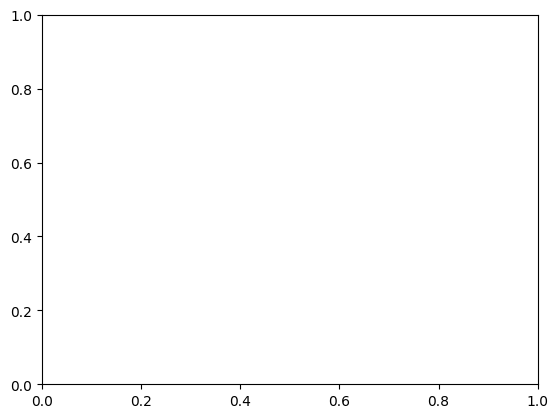

In [ ]:
# labour-augmenting production function

def production_function(K, L):
    return (K ** alpha) *  (L ** (1-alpha))
predicted_output = production_function(df['rnna'], df['emp'])
print(predicted_output)

# labour-augmenting production function


def production_function_per_capita(K, L):
    return A * (K ** alpha)
predicted_output_per_capita = production_function_per_capita(df['rnna'], df['emp'])
print(predicted_output_per_capita)

# actual vs predicted values
df['y_actual'] = (df['rgdpo']/1000) / df['emp']
df['k_actual'] = (df['rnna']/1000) / df['emp']

k_max = df['k_actual'].max() * 1.2 
k_range = np.linspace(0.1, df['k_actual'].max(), 200)

plt.plot(k_range, df['y_actual'], label='Actual Data', marker='o', linestyle='None')
plt.plot(k_range, predicted_output_per_capita, color='red', label='Estimated Production Function')
plt.xlabel("Capital per Worker")
plt.ylabel("Output per Worker")
plt.title("Production Function: South Korea")
plt.legend()
plt.show()

In [115]:


# per capita capital

df['y_actual'] = (df['rgdpo']/1000) / df['emp']
df['k_actual'] =  (df['rnna']/1000) / df['emp']
print(df['k_actual'])

k_range = np.linspace(0.1, df['k_actual'].max(), 200)

# per capita output
def output_per_capita():
    return A ** (1 - alpha) * k_range ** alpha
y_per_capita = output_per_capita()
print(y_per_capita)

# average of the n, g and delta for constant break-even investment
df['g_tfp'] = np.log(df['rtfpna']) - np.log(df['rtfpna'].shift(1))  # TFP growth rate
df['n_g_delta'] = df['emp_growth'] + df['g_tfp'] + df['delta']
n_g_delta_avg = df['n_g_delta'].dropna().mean()
# break-even investment
def break_even_investment():
    return (n_g_delta_avg * k_range)
break_even = break_even_investment()
print(break_even)


print(n_g_delta_avg)


year
1957     27.772617
1958     27.297883
1959     26.515391
1960     25.760909
1961     24.840695
           ...    
2019    482.163680
2020    502.124594
2021    512.391660
2022    513.339951
2023    523.109244
Freq: Y-DEC, Name: k_actual, Length: 67, dtype: float64
[0.39836863 1.05253809 1.28333257 1.44307704 1.56893292 1.67433389
 1.76583408 1.84717588 1.92071868 1.98805565 2.05031839 2.10834253
 2.16276447 2.21408122 2.26268909 2.30890972 2.35300809 2.39520536
 2.43568821 2.47461584 2.5121252  2.54833504 2.58334908 2.61725849
 2.65014389 2.68207694 2.71312166 2.74333552 2.77277027 2.80147276
 2.82948551 2.85684726 2.8835934  2.90975636 2.93536594 2.96044962
 2.98503274 3.00913879 3.03278953 3.0560052  3.07880465 3.10120547
 3.12322408 3.14487588 3.16617529 3.18713586 3.20777032 3.22809066
 3.24810821 3.26783363 3.28727702 3.30644793 3.3253554  3.34400802
 3.36241393 3.38058087 3.3985162  3.41622692 3.43371973 3.45100097
 3.46807675 3.48495284 3.50163482 3.51812798 3.53443741 3.55

### solow curve

In [86]:
pip install sympy

Note: you may need to restart the kernel to use updated packages.


In [118]:
# saving rate
import sympy as sp
df['s'] = df['saving_rate'] = (df['gfcf']/100)
s_mean = df['s'].mean()

print(s_mean)

# s into f of k
def s_f_k():
    return s_mean* y_per_capita
s_f_k_values = s_f_k()
print(s_f_k_values)

0.28578297207949194
[0.11384697 0.30079746 0.3667546  0.41240685 0.44837431 0.47849612
 0.50464531 0.52789141 0.54890869 0.56815245 0.58594608 0.60252839
 0.61808126 0.63274671 0.64663801 0.65984708 0.67244965 0.68450891
 0.69607822 0.70720307 0.71792261 0.72827076 0.73827718 0.74796791
 0.757366   0.76649192 0.77536397 0.78399858 0.79241053 0.80061321
 0.80861878 0.8164383  0.82408189 0.83155882 0.8388776  0.84604609
 0.85307153 0.85996063 0.86671961 0.87335425 0.87986994 0.88627172
 0.89256426 0.89875198 0.90483899 0.91082916 0.91672613 0.92253334
 0.92825402 0.93389121 0.9394478  0.94492652 0.95032995 0.95566055
 0.96092065 0.96611245 0.97123806 0.97629948 0.98129863 0.98623732
 0.99111728 0.99594018 1.00070761 1.00542107 1.01008203 1.01469187
 1.01925193 1.02376349 1.02822777 1.03264596 1.03701918 1.04134853
 1.04563506 1.04987978 1.05408365 1.05824762 1.06237258 1.06645942
 1.07050896 1.07452203 1.0784994  1.08244183 1.08635006 1.09022479
 1.09406671 1.09787648 1.10165475 1.105402

<Axes: xlabel='year', ylabel='k_actual'>

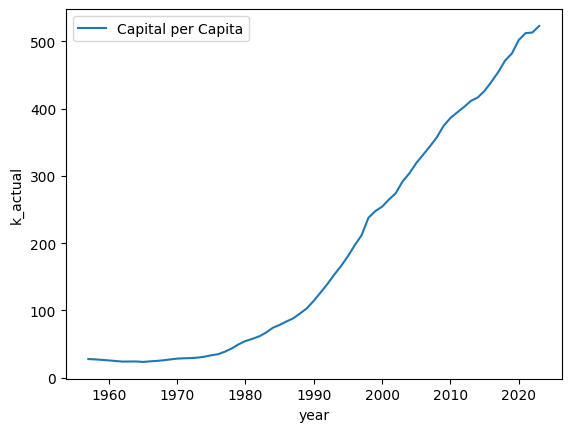

In [100]:
sns.lineplot(x = df.index.to_timestamp(), y = df['k_actual'], label='Capital per Capita')

Text(0, 0.5, 'Output / Investment per Worker')

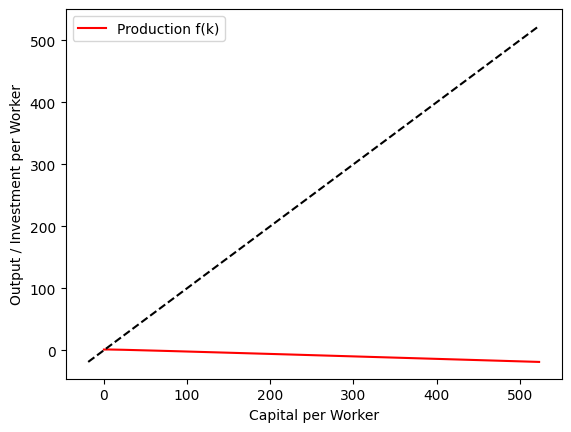

In [ ]:
y_curve = (s_mean * (k_range ** alpha) )   + ((1 - delta_avg * k_range))

ax = sns.lineplot(x=k_range, y=y_curve, label='Production f(k)', color='red')
limits = [min(k_range.min(), y_curve.min()), max(k_range.max(), y_curve.max())]
ax.plot(limits, limits, '--k', label='45 deg line')
plt.xlabel("Capital per Worker")
plt.ylabel("Output / Investment per Worker")

In [110]:
type(k_range)
type(y_per_capita)

pandas.Series

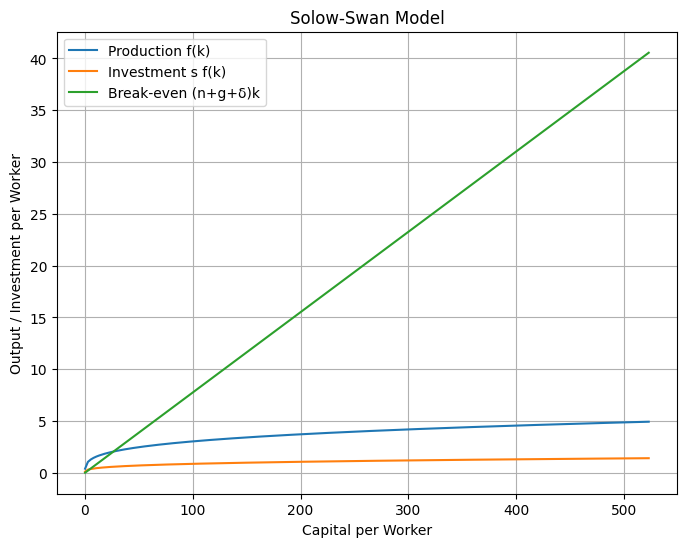

In [119]:
plt.figure(figsize=(8,6))


sns.lineplot(x = k_range, y= y_per_capita , label='Production f(k)')

sns.lineplot(x = k_range, y=s_f_k_values, label='Investment s f(k)')
sns.lineplot(x=k_range, y=break_even, label='Break-even (n+g+δ)k')

plt.xlabel("Capital per Worker")
plt.ylabel("Output / Investment per Worker")
plt.title("Solow-Swan Model")
plt.legend()
plt.grid()

plt.show()

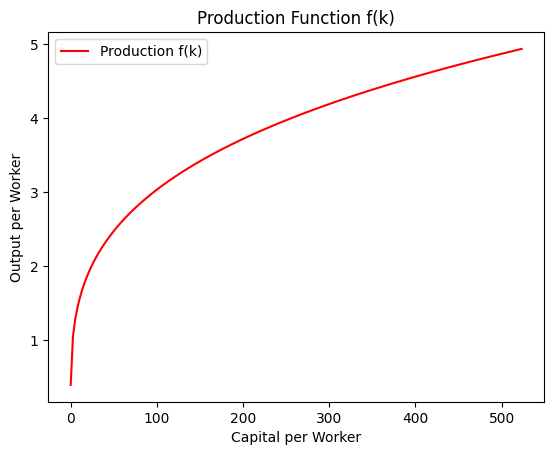

In [120]:
plt.plot(k_range, y_per_capita, label='Production f(k)', color='red')
plt.xlabel("Capital per Worker")
plt.ylabel("Output per Worker")
plt.title("Production Function f(k)") 
plt.legend()
plt.show()

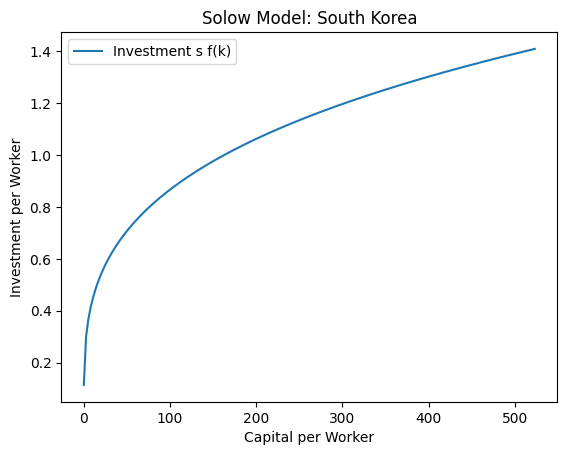

In [121]:
plt.plot(k_range, s_f_k_values , label='Investment s f(k)')
plt.xlabel("Capital per Worker")
plt.ylabel("Investment per Worker")
plt.title("Solow Model: South Korea")
plt.legend()
plt.show()

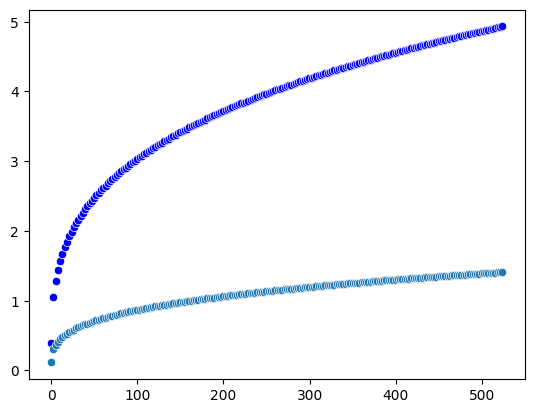

In [122]:
sns.scatterplot(x= k_range, y=y_per_capita, color='blue')
sns.scatterplot(x=k_range, y=s_f_k_values)
plt.show()

In [53]:
print(df['alpha'].dtypes)

float64


6.343968643246003


AttributeError: 'numpy.float64' object has no attribute 'iloc'

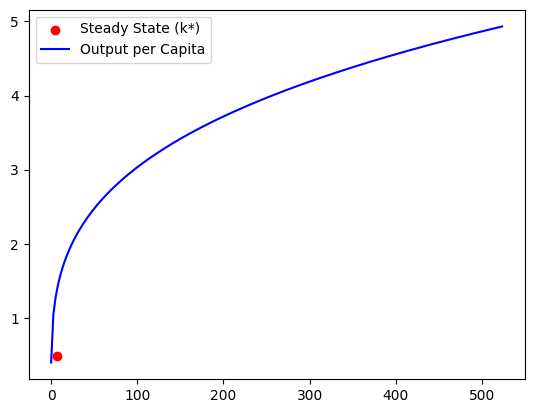

In [126]:
# k star 

k_star = (s_mean / n_g_delta_avg) ** (1/(1-alpha))
print(k_star)
y_star = s_mean * (k_star ** alpha)

plt.scatter(k_star, y_star, color='red', label='Steady State (k*)')
sns.lineplot(x=k_range, y=y_per_capita, color='blue', label='Output per Capita')
plt.text(k_star, y_star, f'k*({k_star.iloc[0]:.2f})', fontsize=10, verticalalignment='bottom')

plt.title('Solow Curve with Steady State')
plt.xlabel('Capital per Capita')    
plt.ylabel('Output per Capita')
plt.legend()
plt.show()


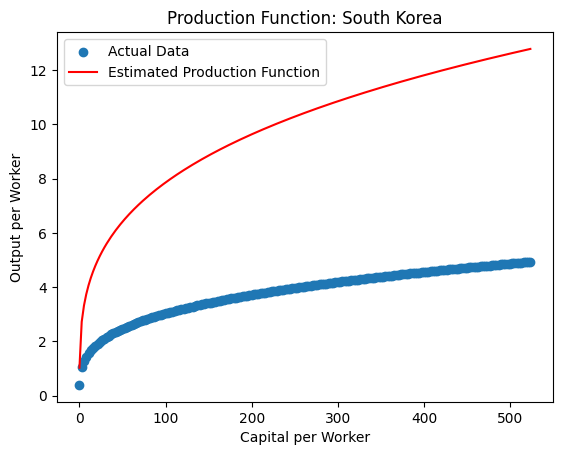

In [129]:

plt.scatter(k_range, y_per_capita, label='Actual Data')

# k_grid = np.linspace(df['k_actual'].min(), df['k_actual'].max(), 200)
y_theory = np.exp(A) * k_range**alpha

plt.plot(k_range, y_theory, color='red', label='Estimated Production Function')

plt.xlabel("Capital per Worker")
plt.ylabel("Output per Worker")
plt.title("Production Function: South Korea")
plt.legend()
plt.show()



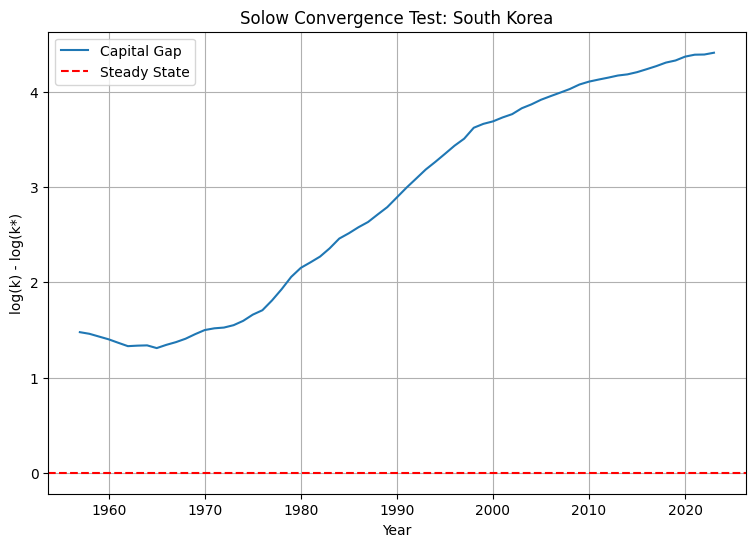

In [130]:
df['capital_gap'] = np.log(df['k_actual']) - np.log(k_star)

plt.figure(figsize=(9,6))

plt.plot(df.index.year, df['capital_gap'], label='Capital Gap')

plt.axhline(0, color='red', linestyle='--', label='Steady State')

plt.title("Solow Convergence Test: South Korea")
plt.xlabel("Year")
plt.ylabel("log(k) - log(k*)")
plt.legend()
plt.grid()

plt.show()

## Break-even regression to identify structural changes

In [56]:
df.columns

Index(['rgdpe', 'rgdpo', 'cgdpe', 'cgdpo', 'cn', 'rgdpna', 'rconna', 'rdana',
       'rnna', 'pop', 'emp', 'irr', 'delta', 'rtfpna', 'export', 'trade',
       'high_exports', 'gfcf', 'log_rgdpo', 'log_rgdpe', 'log_rgdpo_lag1',
       'log_rgdpe_lag1', 'rgdpo_growth', 'rgdpe_growth', 'emp_growth',
       'log_gfcf', 'n_g_delta', 'log_n_g_delta', 'rgdpo_capita',
       'rgdpe_capita', 'fitted_values', 'log_emp', 'log_capital', 'alpha',
       'beta', 'y_actual', 'k_actual', 's', 'saving_rate'],
      dtype='str')

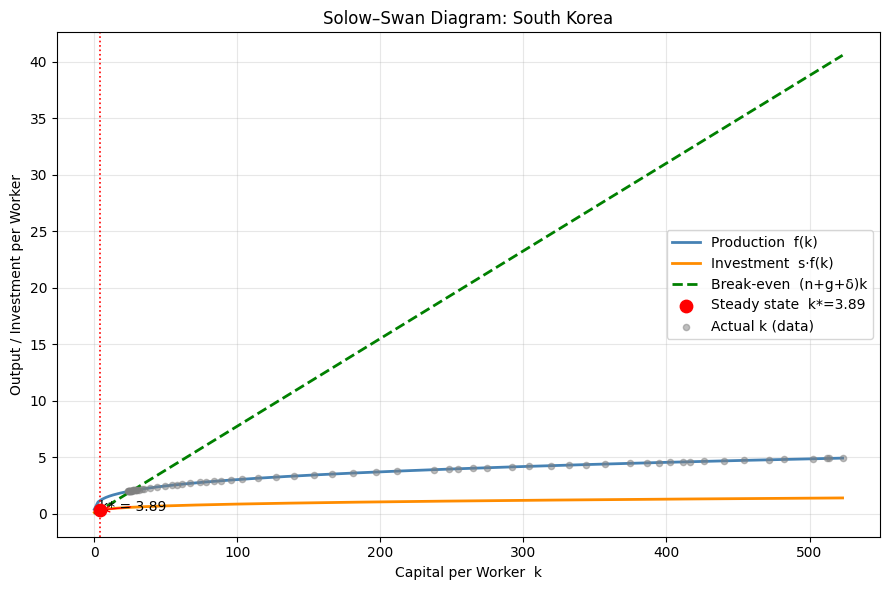

In [131]:


# --- Fixed parameters (use means for a clean theoretical diagram) ---
              # already computed earlier

# --- Smooth capital grid ---


# --- Theoretical curves over the grid ---
y_curve        = A ** (1 - alpha) * k_range ** alpha    # f(k)
s_curve        = s_mean * y_curve                                       # s·f(k)
breakeven_line = n_g_delta_avg* k_range                                   # (n+g+δ)·k

# --- Steady state: s·f(k*) = (n+g+δ)·k*  →  k* = (s/n+g+δ)^(1/(1-α)) ---
k_star_val = (s_mean * A / n_g_delta_avg) ** (1 / (1 - alpha))
y_star_val = A ** (1 - alpha) * k_star_val ** alpha

# --- Plot ---
plt.figure(figsize=(9, 6))

plt.plot(k_range, y_curve,        color='steelblue', linewidth=2,   label='Production  f(k)')
plt.plot(k_range, s_curve,        color='darkorange', linewidth=2,  label='Investment  s·f(k)')
plt.plot(k_range, breakeven_line, color='green',      linewidth=2,  linestyle='--', label='Break-even  (n+g+δ)k')

# Steady-state annotation
plt.axvline(k_star_val, color='red', linestyle=':', linewidth=1.2)
plt.scatter([k_star_val], [s_mean * y_star_val], color='red', zorder=5, s=80, label=f'Steady state  k*={k_star_val:.2f}')
plt.annotate(f'k* = {k_star_val:.2f}',
             xy=(k_star_val, s_mean * y_star_val),
             xytext=(k_star_val + 0.3, s_mean * y_star_val * 0.85),
             arrowprops=dict(arrowstyle='->', color='red'), fontsize=10)

# Actual data points (scatter, not a line)
plt.scatter(df['k_actual'], 
            A ** (1 - alpha) * df['k_actual'] ** alpha,
            color='gray', alpha=0.5, s=20, zorder=3, label='Actual k (data)')

plt.xlabel("Capital per Worker  k")
plt.ylabel("Output / Investment per Worker")
plt.title("Solow–Swan Diagram: South Korea")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()